# Visualization Techniques in EDA

**Course:** Data Preparation for Machine Learning

**EDA (Exploratory Data Analysis)** means looking at the data *before* building any model, to understand its shape, quality, and patterns. Numbers alone (mean, std, min, max) can hide a lot, so we turn them into pictures.

> **Goal:** Convert numerical patterns into visual insights.

| Category | Technique | What it shows |
|---|---|---|
| Distribution Analysis | **Histogram** | Shows feature distribution |
| Distribution Analysis | **Box Plot** | Detects outliers and spread |
| Relationship Analysis | **Scatter Plot** | Shows variable relationships |
| Relationship Analysis | **Heatmap** | Displays correlations |

**Dataset used in this notebook:** a small synthetic *house price* dataset (200 houses) with `area_sqft`, `bedrooms`, `age_years`, `distance_km` (to city center) and `price` (in thousand $). Some outliers are added on purpose so the plots have something interesting to show.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
np.random.seed(42)

# ---------- Create a synthetic house-price dataset ----------
n = 200
area      = np.random.normal(1500, 400, n).clip(500, 3500)        # square feet
bedrooms  = np.random.choice([1, 2, 3, 4, 5], n, p=[0.1, 0.25, 0.35, 0.2, 0.1])
age       = np.random.randint(0, 50, n)                           # years
distance  = np.random.uniform(1, 30, n)                           # km to city center

# price depends on area, bedrooms, age, distance + some noise
price = (50 + 0.12 * area + 15 * bedrooms - 1.2 * age - 2.5 * distance
         + np.random.normal(0, 25, n))

df = pd.DataFrame({
    "area_sqft":   area.round(0),
    "bedrooms":    bedrooms,
    "age_years":   age,
    "distance_km": distance.round(1),
    "price":       price.round(1),
})

# add a few extreme houses (outliers) on purpose
df.loc[[10, 50, 120], "price"] = [520, 560, 600]

print("Shape:", df.shape)
df.head()

Shape: (200, 5)


,area_sqft,bedrooms,age_years,distance_km,price
0,1699.0,4,48,6.0,285.8
1,1445.0,4,24,6.6,252.9
2,1759.0,3,32,2.2,267.6
3,2109.0,4,37,5.9,315.0
4,1406.0,3,5,9.1,241.3


In [ ]:
# Quick numerical summary - the "before" picture. Can you spot the patterns from numbers only?
df.describe().round(2)

---
## 1. Histogram — Distribution Analysis

**What is it?**
A histogram splits a numeric feature into equal-width *bins* and draws a bar for how many values fall in each bin.

**Where is it used?**
- At the very start of EDA, on every numeric column.
- To check the shape of a feature before scaling, transforming, or choosing a model.

**Why is it used?**
- See the **distribution**: normal (bell), skewed left/right, uniform, or multi-peaked.
- Find where most values are concentrated and whether there are gaps or extreme values.
- Decide on preprocessing, e.g. a *right-skewed* feature often needs a log transform; models that assume normality need to know this.

**How to read it?**
- **x-axis** = value ranges (bins), **y-axis** = count (frequency).
- A symmetric bell shape → roughly normal. A long tail on one side → skewed.
- If **mean ≠ median**, the data is skewed (the mean gets pulled toward the tail).
- Bin count matters: too few hides detail, too many looks noisy.

**How to use it in code?** `plt.hist(...)` or `sns.histplot(data, bins=..., kde=True)`.

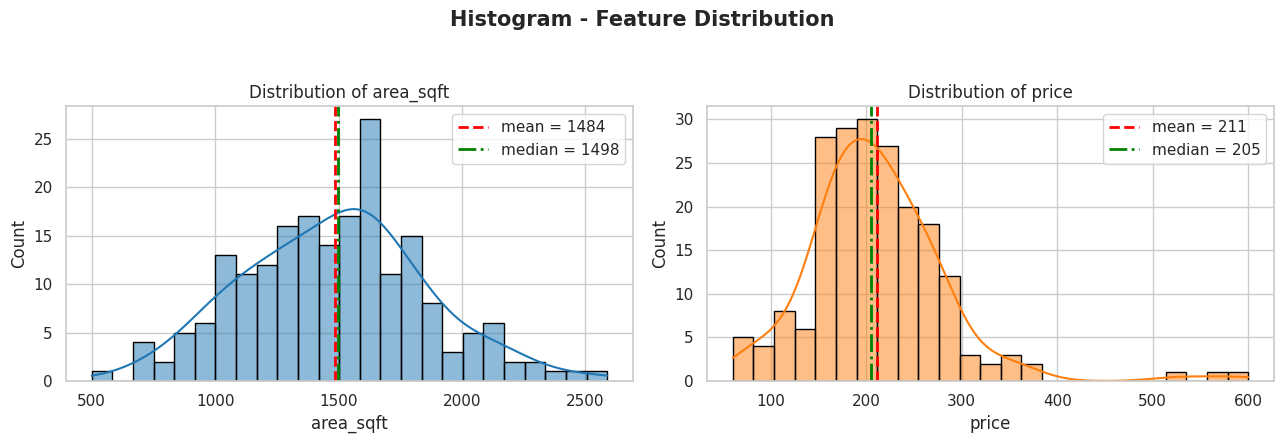

Skewness of area_sqft: 0.15
Skewness of price    : 1.62


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
fig.suptitle("Histogram - Feature Distribution", fontsize=15, fontweight="bold")

for ax, col, color in zip(axes, ["area_sqft", "price"], ["tab:blue", "tab:orange"]):
    sns.histplot(df[col], bins=25, kde=True, color=color, edgecolor="black", ax=ax)
    ax.axvline(df[col].mean(),   color="red",   ls="--", lw=2, label=f"mean = {df[col].mean():.0f}")
    ax.axvline(df[col].median(), color="green", ls="-.", lw=2, label=f"median = {df[col].median():.0f}")
    ax.set_title(f"Distribution of {col}")
    ax.set_xlabel(col); ax.set_ylabel("Count")
    ax.legend()

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# Skewness: 0 = symmetric, > 0 = right-skewed, < 0 = left-skewed
print("Skewness of area_sqft:", round(df["area_sqft"].skew(), 2))
print("Skewness of price    :", round(df["price"].skew(), 2))

**Insight:** `area_sqft` is close to a bell shape (mean ≈ median). `price` has a long right tail caused by a few very expensive houses, so its mean is pulled above the median (right-skewed). A log transform could help before modeling.

---
## 2. Box Plot — Distribution Analysis

**What is it?**
A box plot summarizes a feature using five numbers: **minimum, Q1 (25%), median (50%), Q3 (75%), maximum**. Points far outside the "whiskers" are drawn as individual dots.

**Where is it used?**
- To check for **outliers** in numeric features.
- To compare the spread of a numeric feature across categories (e.g. price for each number of bedrooms).

**Why is it used?**
- Outliers can distort the mean, scaling, and many models (linear regression, k-NN, etc.).
- It shows the **spread** (IQR) and the **median** in one compact picture, and is more robust than a histogram for spotting extreme values.

**How to read it?**
- The **box** covers Q1 to Q3 (the middle 50% of data); the line inside is the **median**.
- **IQR** = Q3 − Q1.
- **Whiskers** extend to the last value within `Q1 − 1.5·IQR` and `Q3 + 1.5·IQR`.
- Dots beyond the whiskers = **potential outliers**.

**How to use it in code?** `sns.boxplot(x=..., y=..., data=df)` or `plt.boxplot(...)`.

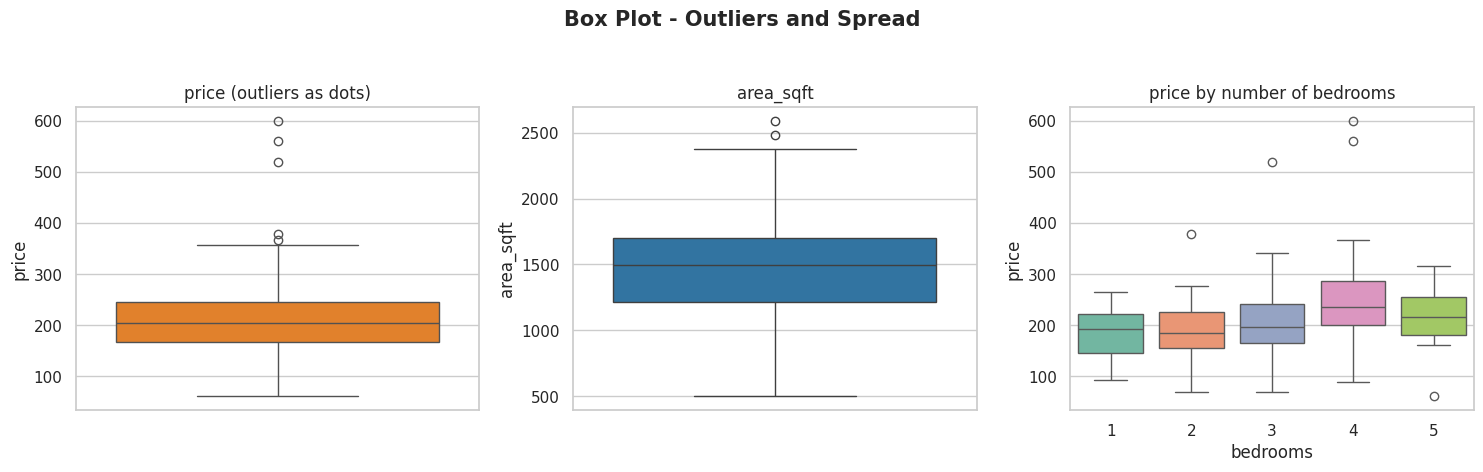

Q1 = 167.6, Q3 = 244.9, IQR = 77.3
Allowed range: [51.7, 360.7]
Number of price outliers: 5


,area_sqft,bedrooms,price
10,1315.0,3,520.0
50,1630.0,4,560.0
106,2254.0,2,377.6
120,1816.0,4,600.0
167,2259.0,4,367.2


In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.8))
fig.suptitle("Box Plot - Outliers and Spread", fontsize=15, fontweight="bold")

# (a) price: single box plot -> outliers visible as dots
sns.boxplot(y=df["price"], color="tab:orange", ax=axes[0])
axes[0].set_title("price (outliers as dots)")

# (b) area_sqft: few or no outliers
sns.boxplot(y=df["area_sqft"], color="tab:blue", ax=axes[1])
axes[1].set_title("area_sqft")

# (c) price grouped by bedrooms: compare spread across categories
sns.boxplot(x="bedrooms", y="price", hue="bedrooms", data=df, palette="Set2", legend=False, ax=axes[2])
axes[2].set_title("price by number of bedrooms")

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

# ---------- Detect outliers numerically with the IQR rule ----------
Q1, Q3 = df["price"].quantile([0.25, 0.75])
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
outliers = df[(df["price"] < lower) | (df["price"] > upper)]

print(f"Q1 = {Q1:.1f}, Q3 = {Q3:.1f}, IQR = {IQR:.1f}")
print(f"Allowed range: [{lower:.1f}, {upper:.1f}]")
print(f"Number of price outliers: {len(outliers)}")
outliers[["area_sqft", "bedrooms", "price"]]

**Insight:** the box plot of `price` shows several dots above the upper whisker, and the IQR rule confirms them numerically. The grouped box plot also shows that median price rises with the number of bedrooms.

---
## 3. Scatter Plot — Relationship Analysis

**What is it?**
A scatter plot puts one numeric variable on the x-axis and another on the y-axis, and draws one dot per row of data.

**Where is it used?**
- To study the relationship between **two numeric variables**, especially a feature and the target (e.g. `area_sqft` vs `price`).
- Before choosing between a linear and a non-linear model.

**Why is it used?**
- Reveals the **direction** (positive / negative), **strength** (tight vs scattered), and **form** (linear, curved) of a relationship.
- Helps spot clusters and outliers that summary statistics can hide.
- A third variable can be added using color or size (e.g. bedrooms).

**How to read it?**
- Dots rising left → right = **positive** relationship; falling = **negative**.
- Dots close to a line = **strong**; a wide cloud = **weak**; no pattern = **no relationship**.
- Isolated dots far from the cloud = outliers.

**How to use it in code?** `plt.scatter(x, y)` or `sns.scatterplot(x=..., y=..., hue=..., data=df)`.

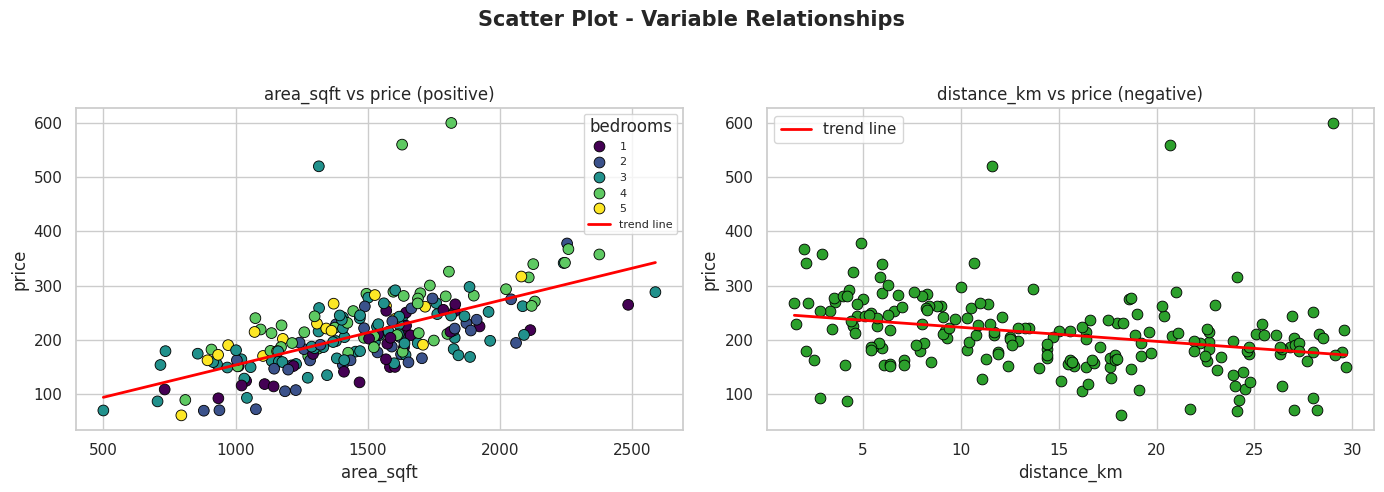

Correlation (area_sqft, price)   : 0.6
Correlation (distance_km, price) : -0.29


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Scatter Plot - Variable Relationships", fontsize=15, fontweight="bold")

# (a) area vs price (positive relationship), colored by bedrooms
sns.scatterplot(x="area_sqft", y="price", hue="bedrooms", palette="viridis",
                data=df, s=60, edgecolor="black", ax=axes[0])
# add a simple trend line
m, c = np.polyfit(df["area_sqft"], df["price"], 1)
xs = np.linspace(df["area_sqft"].min(), df["area_sqft"].max(), 100)
axes[0].plot(xs, m * xs + c, color="red", lw=2, label="trend line")
axes[0].set_title("area_sqft vs price (positive)")
axes[0].legend(title="bedrooms", fontsize=8)

# (b) distance vs price (negative relationship)
sns.scatterplot(x="distance_km", y="price", data=df, color="tab:green",
                s=60, edgecolor="black", ax=axes[1])
m2, c2 = np.polyfit(df["distance_km"], df["price"], 1)
xs2 = np.linspace(df["distance_km"].min(), df["distance_km"].max(), 100)
axes[1].plot(xs2, m2 * xs2 + c2, color="red", lw=2, label="trend line")
axes[1].set_title("distance_km vs price (negative)")
axes[1].legend()

plt.tight_layout(rect=[0, 0, 1, 0.94])
plt.show()

print("Correlation (area_sqft, price)   :", round(df["area_sqft"].corr(df["price"]), 2))
print("Correlation (distance_km, price) :", round(df["distance_km"].corr(df["price"]), 2))

**Insight:** bigger houses cost more (positive relationship), and houses farther from the city center cost less (negative, weaker relationship). The dots that sit far above the trend line are the price outliers we found in the box plot.

---
## 4. Heatmap — Relationship Analysis

**What is it?**
A heatmap shows a matrix of numbers as colors. In EDA it is most often used for the **correlation matrix**, where each cell shows the correlation between two features (from −1 to +1).

**Where is it used?**
- To look at **all numeric features at once** instead of drawing many scatter plots.
- During feature selection, and to detect **multicollinearity** (features that are highly correlated with each other).

**Why is it used?**
- Quickly find which features are strongly related to the **target** (useful predictors).
- Find pairs of features that carry almost the same information (correlation close to ±1) so one can be dropped.
- Compact: one picture summarizes n × n relationships.

**How to read it?**
- **+1** = perfect positive, **−1** = perfect negative, **0** = no *linear* relationship.
- Color intensity = strength; the sign is shown by the color (here red = positive, blue = negative).
- The diagonal is always 1 (a feature with itself).
- Correlation ≠ causation, and it only captures *linear* relationships.

**How to use it in code?** `df.corr()` gives the matrix, then `sns.heatmap(corr, annot=True, cmap="coolwarm")`.

             area_sqft  bedrooms  age_years  distance_km  price
area_sqft         1.00     -0.05       0.09        -0.06   0.60
bedrooms         -0.05      1.00       0.09        -0.06   0.27
age_years         0.09      0.09       1.00         0.06  -0.10
distance_km      -0.06     -0.06       0.06         1.00  -0.29
price             0.60      0.27      -0.10        -0.29   1.00


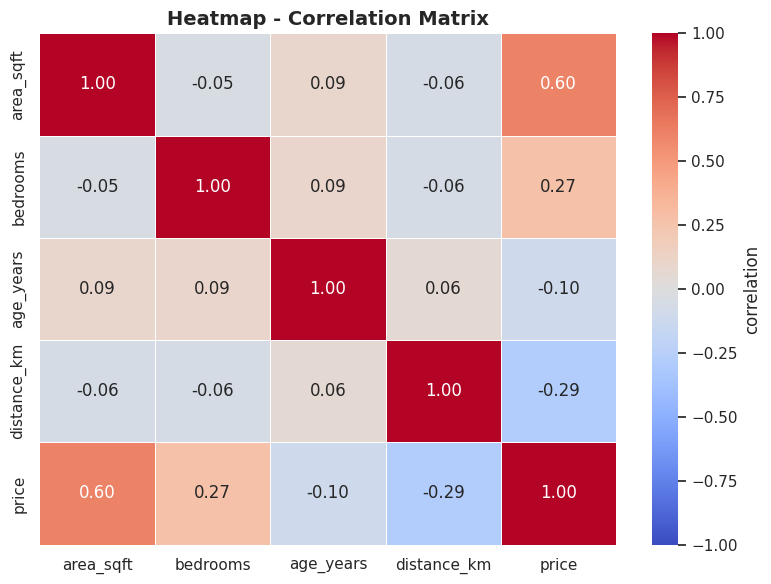


Correlation with price (sorted):
area_sqft      0.60
bedrooms       0.27
age_years     -0.10
distance_km   -0.29
Name: price, dtype: float64


In [ ]:
# Correlation matrix of all numeric features
corr = df.corr(numeric_only=True)
print(corr.round(2))

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm",
            vmin=-1, vmax=1, center=0, linewidths=0.5,
            cbar_kws={"label": "correlation"})
plt.title("Heatmap - Correlation Matrix", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

# Correlation of every feature with the target
print("\nCorrelation with price (sorted):")
print(corr["price"].drop("price").sort_values(ascending=False).round(2))

**Insight:** `area_sqft` has the strongest positive correlation with `price`, followed by `bedrooms`. `distance_km` is negatively correlated, while `age_years` is almost uncorrelated (close to 0) in this dataset. No two input features are strongly correlated with each other, so multicollinearity is not a concern here.

---
## Summary

| Technique | Type | Question it answers | Look for |
|---|---|---|---|
| Histogram | Distribution | How are the values spread? | Skewness, peaks, gaps |
| Box Plot | Distribution | Are there outliers? How wide is the spread? | Dots beyond whiskers, IQR |
| Scatter Plot | Relationship | How do two variables relate? | Direction, strength, shape |
| Heatmap | Relationship | Which features are correlated? | Strong colors, redundant features |

**Goal:** Convert numerical patterns into visual insights, so that we clean and prepare the data better *before* Machine Learning.